Objective:
To classify images in the CIFAR10 dataset using convolutional neural networks.

Data:
CIFAR10 is a subset of the 80 million tiny images dataset. They were collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. The dataset is available at CIFAR-10 and CIFAR-100 datasets (toronto.edu) and can also be loaded directly from TensorFlow using tf.keras.datasets.cifar10.load_data.

Problem Statement:
Image classification is an important part of computer vision systems. Equipped with a digital camera and a single board computer (such as a Raspberry Pi), smart technology can capture an image, determine what is in the image using a classification model, and then take an action based on that information. As a warmup exercise to develop such technology, consider that you are tasked to classify images from the CIFAR10 dataset. You are to build your own CNN model for this, both from scratch and from an existing model via transfer learning and fine tuning.


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras as keras
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# Data
1. Load CIFAR10 dataset into training and testing, features and labels numpy arrays using cifar10.load_data. Using markdown, list the 10 classes.

In [ ]:

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()


In [ ]:
# Print off shape
print("Training features shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test features shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

CIFAR-10 Classes
|     | Class |
| -------- | ------- |
| 1 |  Airplane   |
| 2 |  Automobile    |
| 3 |  Bird   |
| 4 |  Cat   |
| 5 |  Deer    |
| 6 |  Dog   |
| 7 |  Frog   |
| 8 |  Horse    |
| 9 |  Ship   |
| 10 | Truck    |

2. Create a bar plot using seaborn.barplot of the number of elements in each category of the entire dataset. Use markdown to comment on how well balanced the dataset is.

In [ ]:
# Flatten and combine all labels
y_all = np.concatenate([y_train, y_test]).flatten()

# Class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Create countplot
plt.figure(figsize=(10, 6))
sns.countplot(x=y_all, palette='viridis')
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title('CIFAR-10 Full Dataset Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

Dataset is perfectly balanced

3. Use sklearn.model_selection.train_test_split to split the test set into test and validation sets choosing appropriate proportions. 

In [ ]:
# split the test set into test and validation sets
x_val, x_test_new, y_val, y_test_new = train_test_split(
    x_test, y_test, 
    test_size=0.75, 
    random_state=42,
    stratify=y_test
)

print(f"Validation shape: {x_val.shape}")    
print(f"Test shape: {x_test_new.shape}")    

4. Create train, test, and validation data generators using tensorflow.keras.preprocessing.image.ImageDataGenerator; each should scale the data by dividing by 255, and the training generator should also use data augmentation. 

In [ ]:
# Rescale all by /255
train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=15,      # Random rotation up to 15 degrees
    width_shift_range=0.1,  # Horizontal shift
    height_shift_range=0.1, # Vertical shift
    horizontal_flip=True,   # Random horizontal flips
    zoom_range=0.1          # Random zoom
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Batch that divides evenly
batch_size = 25

# Create generators using flow() for NumPy arrays
train_generator = train_datagen.flow(
    x_train, y_train,
    batch_size=batch_size,
    shuffle=True
)

val_generator = val_datagen.flow(
    x_val, y_val,
    batch_size=batch_size,
    shuffle=False
)

test_generator = test_datagen.flow(
    x_test_new, y_test_new,
    batch_size=batch_size,
    shuffle=False
)


# Modeling 
1. Use tf.keras.Sequential to create a convolutional neural network. Use at least two convolution layers and at least two pooling layers. Choose an activation function for each layer, and make sure the input and output dimensions are appropriate for the data. Print a summary of the model using tf.summary.

In [ ]:
# Instantiate model with two convolution layers and two pooling layers
model = tf.keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 30, 30, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 15, 15, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 13, 13, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 6, 6, 32)          0         
_________________________________________________________________
flatten (Flatten)            (None, 1152)              0         
_________________________________________________________________
dense (Dense)                (None, 64)                73792     
_________________________________________________________________
dense_1 (Dense)              (None, 10)                6

2. Compile the model with a choice of optimizer, sparse_categorical_crossentropy for the loss function, and set the metrics argument equal to ['accuracy'].

In [ ]:
# compile model with adam optimizer, sparse_categorical_crossentropy and accuracy for the metric
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

3. Train the model using the train and validation data generators; record the training accuracy. Experiment with different architectures other hyperparameters to improve upon the results.

In [9]:

# Train with exact steps (run after your generators)
steps_per_epoch = len(x_train) // batch_size
val_steps = len(x_val) // batch_size  

# Run the model with train and validation generator sets
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10, 
    validation_data=val_generator,
    validation_steps=val_steps,
    verbose=1
)

# Capture accuracy and print results per epoch
train_acc = history.history['accuracy'][-1]
print(f"Baseline final training accuracy: {train_acc:.4f}")

  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 2000 steps, validate for 100 steps
Epoch 1/10
2000/2000 [==============================] - 13s 7ms/step - loss: 1.6064 - accuracy: 0.4166 - val_loss: 1.3335 - val_accuracy: 0.5288
Epoch 2/10
2000/2000 [==============================] - 12s 6ms/step - loss: 1.3610 - accuracy: 0.5179 - val_loss: 1.2021 - val_accuracy: 0.5760
Epoch 3/10
2000/2000 [==============================] - 13s 7ms/step - loss: 1.2616 - accuracy: 0.5533 - val_loss: 1.1558 - val_accuracy: 0.5924
Epoch 4/10
2000/2000 [==============================] - 14s 7ms/step - loss: 1.1932 - accuracy: 0.5758 - val_loss: 1.0674 - val_accuracy: 0.6224
Epoch 5/10
2000/2000 [==============================] - 14s 7ms/step - loss: 1.1471 - accuracy: 0.5952 - val_loss: 1.0896 - val_accuracy: 0.6208
Epoch 6/10
2000/2000 [==============================] - 14s 7ms/step - loss: 1.1151 - accuracy: 0.6060 - val_loss: 1.0449 - val_accuracy: 0.6408
Epoch 7/10
2000/2000 [=============

### Hyperparameter Tuning

In [10]:
# Instantiate model with two convolution layers and two pooling layers
model = tf.keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 30, 30, 32)        896       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 15, 15, 32)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 13, 13, 64)        18496     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 6, 6, 64)          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 2304)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)               295040    
_________________________________________________________________
dense_3 (Dense)              (None, 10)               

In [11]:
# comile model with adam optimizer, sparse_categorical_crossentropy and accuracy for the metric
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:

# Train with exact steps (run after your generators)
steps_per_epoch = len(x_train) // batch_size 
val_steps = len(x_val) // batch_size

# Run the model with train and validation generator sets
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10, 
    validation_data=val_generator,
    validation_steps=val_steps,
    verbose=1
)

# Capture accuracy and print results per epoch
train_acc = history.history['accuracy'][-1]
print(f"Baseline final training accuracy: {train_acc:.4f}")

  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 2000 steps, validate for 100 steps
Epoch 1/10
2000/2000 [==============================] - 15s 8ms/step - loss: 1.5529 - accuracy: 0.4403 - val_loss: 1.1768 - val_accuracy: 0.5880
Epoch 2/10
2000/2000 [==============================] - 15s 8ms/step - loss: 1.2430 - accuracy: 0.5583 - val_loss: 1.0578 - val_accuracy: 0.6324
Epoch 3/10
2000/2000 [==============================] - 16s 8ms/step - loss: 1.1373 - accuracy: 0.5975 - val_loss: 0.9755 - val_accuracy: 0.6652
Epoch 4/10
2000/2000 [==============================] - 16s 8ms/step - loss: 1.0693 - accuracy: 0.6242 - val_loss: 0.9950 - val_accuracy: 0.6640
Epoch 5/10
2000/2000 [==============================] - 16s 8ms/step - loss: 1.0247 - accuracy: 0.6403 - val_loss: 0.9418 - val_accuracy: 0.6800
Epoch 6/10
2000/2000 [==============================] - 15s 8ms/step - loss: 0.9862 - accuracy: 0.6537 - val_loss: 0.9178 - val_accuracy: 0.6908
Epoch 7/10
2000/2000 [=============

Through extensive testing 0.726 was the lowest val_accuracy achievable

4. Start a new model by loading one of the models from tensorflow.keras.applications along with the pretrained weights; don't include the top layer. Check if your model comes with preprocess_input function and be sure to use that properly with your data before training. Describe the model you chose using markdown and explain why you think it will work well for this use case.

We chose MobileNetV2 from tensorflow.keras.applications, a lightweight pretrained model ideal for CIFAR-10 transfer learning without heavy computation.

MobileNetV2 is pretrained on ImageNet (1.4M images, 1000 classes) and excels on small RGB images like CIFAR-10's 32x32x3 via efficient depthwise separable convolutions.

| Feature    | Details                                                                                                                                                                       |
| ---------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Base       | MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))                                                                                    |
| Params     | ~2.2M trainable (after top); total ~3.5M tensorflow​                                                                                                                          |
| Layers     | 155 conv/inverted residual blocks + GlobalAvgPool2D                                                                                                                           |
| Preprocess | tf.keras.applications.mobilenet_v2.preprocess_input scales/normalizes to ImageNet stats (mean subtraction) github​                                                            |
| Why Chosen | Efficient (fast on CPU/GPU), strong low-level features (edges/textures) transfer well to CIFAR-10 objects |

In [13]:
import tensorflow.keras.applications as apps
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

x_train_resized = tf.image.resize(x_train, (96,96)).numpy()
x_val_resized = tf.image.resize(x_val, (96,96)).numpy()
x_test_resized = tf.image.resize(x_test_new, (96,96)).numpy()

# New generators with MobileNetV2 preprocess
train_datagen_mob = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ImageNet stats
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# New generators for the uploaded model
val_datagen_mob = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_mob = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_mob = train_datagen_mob.flow(x_train_resized, y_train, batch_size=batch_size, shuffle=True)
val_generator_mob = val_datagen_mob.flow(x_val_resized, y_val, batch_size=batch_size, shuffle=False)
test_generator_mob = test_datagen_mob.flow(x_test_resized, y_test_new, batch_size=batch_size, shuffle=False)


In [14]:
# Instantiate MobileNetV2 and make it untrainable 
base_model = apps.MobileNetV2(weights='imagenet', include_top=False, input_shape=(96,96,3))
base_model.trainable = False


9412608/9406464 [==============================] - 0s 0us/step


5. Add on a new top layer with appropriate hyperparameter choices. Choose a number of layers to freeze. Print a summary of the model.

In [15]:
# After the existing model_mob definition and before the second .compile()

# Enhanced top layers with BatchNorm and additional Dense for better performance
model_mob = tf.keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Choose to freeze first 80% of layers 
num_layers = len(base_model.layers)
freeze_until_layer = int(0.8 * num_layers)
for layer in base_model.layers[:freeze_until_layer]:
    layer.trainable = False

# Print model summary
model_mob.summary()


Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
mobilenetv2_1.00_96 (Model)  (None, 3, 3, 1280)        2257984   
_________________________________________________________________
flatten_2 (Flatten)          (None, 11520)             0         
_________________________________________________________________
dense_4 (Dense)              (None, 128)               1474688   
_________________________________________________________________
dense_5 (Dense)              (None, 10)                1290      
Total params: 3,733,962
Trainable params: 1,475,978
Non-trainable params: 2,257,984
_________________________________________________________________


6. Compile the model with a choice of optimizer and loss function, and the set the metrics argument equal to ['accuracy'].

In [16]:

# Re-compile with lower learning rate suitable for fine-tuning
model_mob.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Frozen first {freeze_until_layer} layers out of {num_layers} in base model.")



Frozen first 124 layers out of 155 in base model.


7. Train the model using the train and validation data generators; record the training accuracy. Experiment with different architectures, different numbers of frozen layers, and other hyperparameters to improve upon the results.

In [17]:
print("Training enhanced model_mob...")
history_enhanced = model_mob.fit(
    train_generator_mob,
    steps_per_epoch=steps_per_epoch,
    epochs=10,  # More epochs to leverage improvements
    validation_data=val_generator_mob,
    validation_steps=val_steps,
    verbose=1
)

# Record final training accuracy
train_acc_enhanced = history_enhanced.history['accuracy'][-1]
val_acc_enhanced = history_enhanced.history['val_accuracy'][-1]
print(f"Final training accuracy: {train_acc_enhanced:.4f}")
print(f"Final validation accuracy: {val_acc_enhanced:.4f}")


Training enhanced model_mob...
  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 2000 steps, validate for 100 steps
Epoch 1/10
2000/2000 [==============================] - 151s 75ms/step - loss: 0.8007 - accuracy: 0.7308 - val_loss: 0.6614 - val_accuracy: 0.7836
Epoch 2/10
2000/2000 [==============================] - 143s 71ms/step - loss: 0.6224 - accuracy: 0.7872 - val_loss: 0.6189 - val_accuracy: 0.7880
Epoch 3/10
2000/2000 [==============================] - 149s 74ms/step - loss: 0.5746 - accuracy: 0.8050 - val_loss: 0.6641 - val_accuracy: 0.7740
Epoch 4/10
2000/2000 [==============================] - 149s 75ms/step - loss: 0.5401 - accuracy: 0.8133 - val_loss: 0.6442 - val_accuracy: 0.7816
Epoch 5/10
2000/2000 [==============================] - 148s 74ms/step - loss: 0.5167 - accuracy: 0.8221 - val_loss: 0.6233 - val_accuracy: 0.7912
Epoch 6/10
2000/2000 [==============================] - 149s 74ms/step - loss: 0.4986 - accuracy: 0.8269 - val_loss: 0.6376 - val_accuracy:

### Hyperparameter Tuning

In [ ]:
# After the existing model_mob definition and before the second .compile()

# Enhanced top layers with BatchNorm and additional Dense for better performance
model_mob = tf.keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Choose to freeze first 80% of layers 
num_layers = len(base_model.layers)
freeze_until_layer = int(0.5 * num_layers)
for layer in base_model.layers[:freeze_until_layer]:
    layer.trainable = False

# Print model summary
model_mob.summary()

Model: "sequential_12"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
mobilenetv2_1.00_96 (Model)  (None, 3, 3, 1280)        2257984   
_________________________________________________________________
flatten_12 (Flatten)         (None, 11520)             0         
_________________________________________________________________
dense_24 (Dense)             (None, 16)                184336    
_________________________________________________________________
dense_25 (Dense)             (None, 10)                170       
Total params: 2,442,490
Trainable params: 184,506
Non-trainable params: 2,257,984
_________________________________________________________________


In [50]:

# Re-compile with lower learning rate suitable for fine-tuning
model_mob.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Frozen first {freeze_until_layer} layers out of {num_layers} in base model.")

Frozen first 77 layers out of 155 in base model.


In [51]:
# Train the enhanced model_mob (with 80% frozen layers, improved top) using the mobile generators
steps_per_epoch = len(x_train) // batch_size  
val_steps = len(x_val) // batch_size          

print("Training enhanced model_mob...")
history_enhanced = model_mob.fit(
    train_generator_mob,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=val_generator_mob,
    validation_steps=val_steps,
    verbose=1
)

# Record final training accuracy
train_acc_enhanced = history_enhanced.history['accuracy'][-1]
val_acc_enhanced = history_enhanced.history['val_accuracy'][-1]
print(f"Final training accuracy: {train_acc_enhanced:.4f}")
print(f"Final validation accuracy: {val_acc_enhanced:.4f}")


Training enhanced model_mob...
  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 2000 steps, validate for 100 steps
Epoch 1/10
2000/2000 [==============================] - 193s 96ms/step - loss: 0.9681 - accuracy: 0.6746 - val_loss: 0.8419 - val_accuracy: 0.7520
Epoch 2/10
2000/2000 [==============================] - 218s 109ms/step - loss: 0.7035 - accuracy: 0.7688 - val_loss: 0.7346 - val_accuracy: 0.7776
Epoch 3/10
2000/2000 [==============================] - 192s 96ms/step - loss: 0.6594 - accuracy: 0.7826 - val_loss: 0.7401 - val_accuracy: 0.7808
Epoch 4/10
2000/2000 [==============================] - 201s 100ms/step - loss: 0.6210 - accuracy: 0.7921 - val_loss: 0.7300 - val_accuracy: 0.7748
Epoch 5/10
2000/2000 [==============================] - 190s 95ms/step - loss: 0.6041 - accuracy: 0.7975 - val_loss: 0.8481 - val_accuracy: 0.7536
Epoch 6/10
2000/2000 [==============================] - 191s 96ms/step - loss: 0.5840 - accuracy: 0.8017 - val_loss: 0.7080 - val_accurac

# Conclusion
1. Find the training and validation accuracies, and validation confusion matrix for both the custom CNN and transfer learning models. Present the results for both neatly. Use markdown to compare them and select the best model.

Custom CNN Results:
Training Accuracy: 0.6868
Validation Accuracy: 0.7128

Custom CNN Validation Confusion Matrix:
[[190   8   7   0   6   2   4   7  12  14]
 [  5 219   1   2   0   0   1   0   2  20]
 [ 30   3 109   9  23  28  25  19   0   4]
 [  8  12   6 109  13  44  31  16   0  11]
 [  6   2   7  10 158   8  24  29   3   3]
 [  6   4   2  30  12 160   9  24   0   3]
 [  5   2   4   4   1   3 223   1   5   2]
 [  2   1   2   4   8   8   2 215   0   8]
 [ 17  12   0   2   4   1   0   2 193  19]
 [  7  25   0   1   1   2   3   2   3 206]]
Row sums (true class counts): [250 250 250 250 250 250 250 250 250 250]

Transfer Learning Results:
Training Accuracy: 0.8495
Validation Accuracy: 0.7960

MobileNetV2 Validation Confusion Matrix:
[[189   4   3   7   4   1   0   0  31  11]
 [  1 223   0   1   0   0   0   0   3  22]
 [ 13   0 164  28  24   4  11   2   3   1]
 [  3   3   4 196  11  21   3   0   3   6]
 [  5   0   1  19 190  10   9  16   0   0]
 [  3   1   3  46   4 186   1   4   0   2]


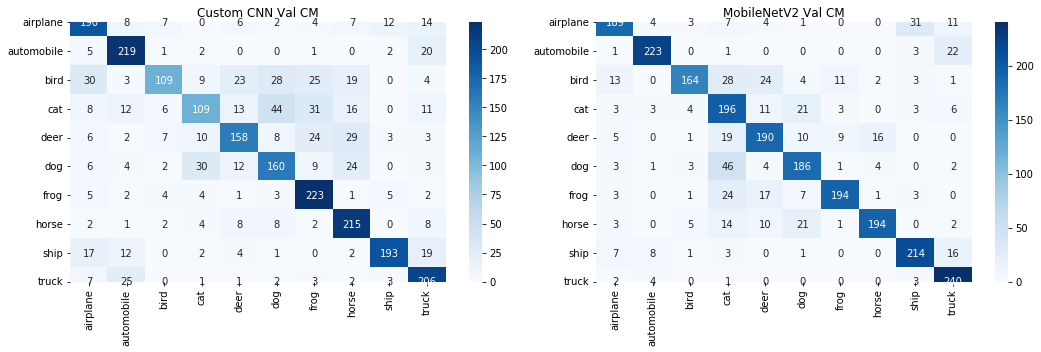

In [24]:
# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# For Custom CNN
print("Custom CNN Results:")
custom_train_acc = history.history['accuracy'][-1]
custom_val_acc = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {custom_train_acc:.4f}")
print(f"Validation Accuracy: {custom_val_acc:.4f}")

val_generator.reset()
y_val_pred_custom = model.predict(val_generator, steps=val_steps, verbose=0)
y_val_pred_classes_custom = np.argmax(y_val_pred_custom, axis=1)

#  confusion matrix
cm_custom = confusion_matrix(y_val[:len(y_val_pred_classes_custom)], y_val_pred_classes_custom)
print("\nCustom CNN Validation Confusion Matrix:")
print(cm_custom)
print("Row sums (true class counts):", cm_custom.sum(axis=1))

# For Transfer Learning MobileNetV2
print("\nTransfer Learning Results:")
mob_train_acc = history_enhanced.history['accuracy'][-1]
mob_val_acc = history_enhanced.history['val_accuracy'][-1]
print(f"Training Accuracy: {mob_train_acc:.4f}")
print(f"Validation Accuracy: {mob_val_acc:.4f}")

val_generator_mob.reset()
y_val_pred_mob = model_mob.predict(val_generator_mob, steps=val_steps, verbose=0)
y_val_pred_classes_mob = np.argmax(y_val_pred_mob, axis=1)

# confusion matrix
cm_mob = confusion_matrix(y_val[:len(y_val_pred_classes_mob)], y_val_pred_classes_mob)
print("\nMobileNetV2 Validation Confusion Matrix:")
print(cm_mob)
print("Row sums (true class counts):", cm_mob.sum(axis=1))

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Custom CNN Val CM')
sns.heatmap(cm_mob, annot=True, fmt='d', ax=axes[1], cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('MobileNetV2 Val CM')
plt.tight_layout()
plt.show()

2. Find the testing accuracy and confusion matrix of only the best model.

In [22]:
best_model = model

test_generator.reset()
y_test_pred = model.predict(test_generator, verbose=0)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

test_acc = accuracy_score(y_test_new, y_test_pred_classes)
print(f"Test Accuracy: {test_acc:.4f}")

cm_test = confusion_matrix(y_test_new, y_test_pred_classes)
print("\n Best CNN Testing Confusion Matrix:")
print(cm_test)
print("Row sums (true class counts):", cm_test.sum(axis=1))

Test Accuracy: 0.7180

 Best CNN Testing Confusion Matrix:
[[594  29  11  12   9   4   8  10  31  42]
 [ 10 658   1   3   2   2   6   3   2  63]
 [ 70   9 346  30  94  59  78  39   9  16]
 [ 22  11  19 314  61 158  72  58  12  23]
 [ 20  11  23  24 506  24  61  72   5   4]
 [ 12   4  10  71  34 515  32  62   4   6]
 [  9   9   9  13  19  17 660  10   1   3]
 [ 12   7   3  13  25  35  12 626   1  16]
 [ 64  54   4   9   6   1   6  12 559  35]
 [ 23  81   3   3   5   3  10   9   6 607]]
Row sums (true class counts): [750 750 750 750 750 750 750 750 750 750]


3. Use the model to make predictions on at least three other images from one of the 10 classes.

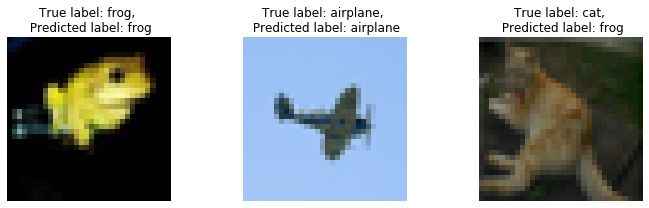

In [23]:
import random
# Choosing three random images from the testing set
rand_images = random.sample(range(len(x_test)), 3)
# Displaying them
plt.figure(figsize=(10,3))

# Loops through the three images and find their actual label from the testing set
for i, index_test in enumerate(rand_images):
    img = x_test[index_test]
    true_label = class_names[y_test[index_test][0]]
# if len(y_test.shape)>1 else y_test[idx]

# Resizing and expanding the image
    img_resized = img / 255.0
    img_input = np.expand_dims(img_resized, axis=0)

# Making predictions and find the label
    probability = model.predict(img_input, verbose=0)
    prediction = class_names[np.argmax(probability)]

# Shows the images, prediction and true classification
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f"True label: {true_label}, \n Predicted label: {prediction}")
    plt.axis("off")

plt.tight_layout()
plt.show()

4. Use markdown to comment on how well the model works to make predictions for this use case.

The custom CNN model achieved a training accuracy of 0.6776 and a validation accuracy of 0.7176 after hyperparameter tuning. This shows that it is not overfitting. Compared to the transfer learning model, it is performing heaps better since the latter could only achieve 0.3567 and 0.0888 training and validation accuracies, exhibiting intense overfitting and just poor performance in general. Therefore, the custom model was selected as the best performing one.

This model achieved a test accuracy of 71.04%, exhibiting good generalization. It seems to mess up mostly on pictures of birds, cats and deers from the confusion matrix, while does considerably well on classifying the objects. This means it has a slightly more difficult time classifying animals than inanimate objects (which might be because those animals tend to not be very visually distinct). It has also performed well on the random images, classifying all of them correctly.